# Clasificación: TMDB Movie Dataset

## Objetivo
Se implementan dos tareas de clasificación sobre el dataset de películas TMDB:

**Clasificación 1 — `highly_rated` (binaria)**
Predecir si una película será bien valorada (vote_average ≥ 7.0)
basándose en características de producción y metadata.

**Clasificación 2 — `success_category` (multiclase, 4 clases)**
Predecir el tipo de éxito de una película combinando rating y popularidad:
- Success: bien valorada Y popular
- Critically Acclaimed: bien valorada, no popular
- Commercial Hit: popular, no bien valorada
- Standard: ninguna de las anteriores

## Algoritmos
- Gaussian Naive Bayes
- Red Bayesiana (pgmpy)
- Random Forest

## Validación
Validación cruzada estratificada 10-fold (como indicado en clase)
F1-Score como métrica principal dado el desbalance de clases.

In [1]:
#!pip install pgmpy 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,ConfusionMatrixDisplay, f1_score,precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120 #Matplotlib images resolution
print("Librerías cargadas correctamente.")

C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [3]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()

print(f"Dataset: {df.shape[0]:,} películas | {df.shape[1]} variables")
print(f"\nColumnas disponibles:\n{list(df.columns)}")

Dataset: 116,929 películas | 23 variables

Columnas disponibles:
['id', 'title', 'vote_average', 'vote_count', 'release_date', 'runtime', 'adult', 'original_language', 'overview', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'release_year', 'duration_bin', 'highly_rated', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']


In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

# ── Codificar original_language ───────────────────────────────────────────────
top_langs = df['original_language'].value_counts().nlargest(10).index
df['lang_encoded'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)
le = LabelEncoder()
df['lang_encoded'] = le.fit_transform(df['lang_encoded'])

# ── adult a entero ────────────────────────────────────────────────────────────
df['adult_int'] = df['adult'].astype(int)

# ── duration_bin a ordinal ────────────────────────────────────────────────────
duration_map = {'Short': 0, 'Standard': 1, 'Long': 2, 'Very long': 3}
df['duration_encoded'] = df['duration_bin'].map(duration_map)

# ── Genres con MultiLabelBinarizer ────────────────────────────────────────────
df['genres_list'] = df['genres'].fillna('').apply(
    lambda x: [g.strip() for g in x.split(',') if g.strip() != '']
)
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df['genres_list'])
df_genres = pd.DataFrame(genres_encoded, columns=[f'genre_{g}' for g in mlb.classes_])
df_genres.index = df.index

GENRE_COLS = list(df_genres.columns)
print(f"Géneros codificados ({len(GENRE_COLS)}): {GENRE_COLS}")

# ── Features base (para Red Bayesiana — sin PCA ni genres) ───────────────────
FEATURES_BASE = ['vote_count', 'runtime', 'release_year',
                 'adult_int', 'lang_encoded', 'duration_encoded']

# ── Features completas Clasificación 1 — highly_rated ────────────────────────
# NO usar PC1 (carga vote_average directamente)
# NO usar popularity, vote_average, highly_rated (target o deriva del target)
PCA_C1 = ['PC2', 'PC3', 'PC4', 'PC5']
FEATURES_C1 = FEATURES_BASE + PCA_C1 + GENRE_COLS

# ── Features completas Clasificación 2 — success_category ────────────────────
# Aquí PC1 sí es seguro
PCA_C2 = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
FEATURES_C2 = FEATURES_BASE + PCA_C2 + GENRE_COLS

print(f"\nFeatures Clasificación 1 (highly_rated):      {len(FEATURES_C1)} columnas")
print(f"Features Clasificación 2 (success_category):  {len(FEATURES_C2)} columnas")
print(f"Features Red Bayesiana (base):                {len(FEATURES_BASE)} columnas")

Géneros codificados (19): ['genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']

Features Clasificación 1 (highly_rated):      29 columnas
Features Clasificación 2 (success_category):  30 columnas
Features Red Bayesiana (base):                6 columnas


── Target 1: highly_rated ──────────────────────────────
highly_rated
0    0.832
1    0.168
Name: proportion, dtype: float64

── Target 2: success_category ──────────────────────────
success_category
Standard                0.642
Commercial Hit          0.190
Critically Acclaimed    0.108
Success                 0.060
Name: proportion, dtype: float64


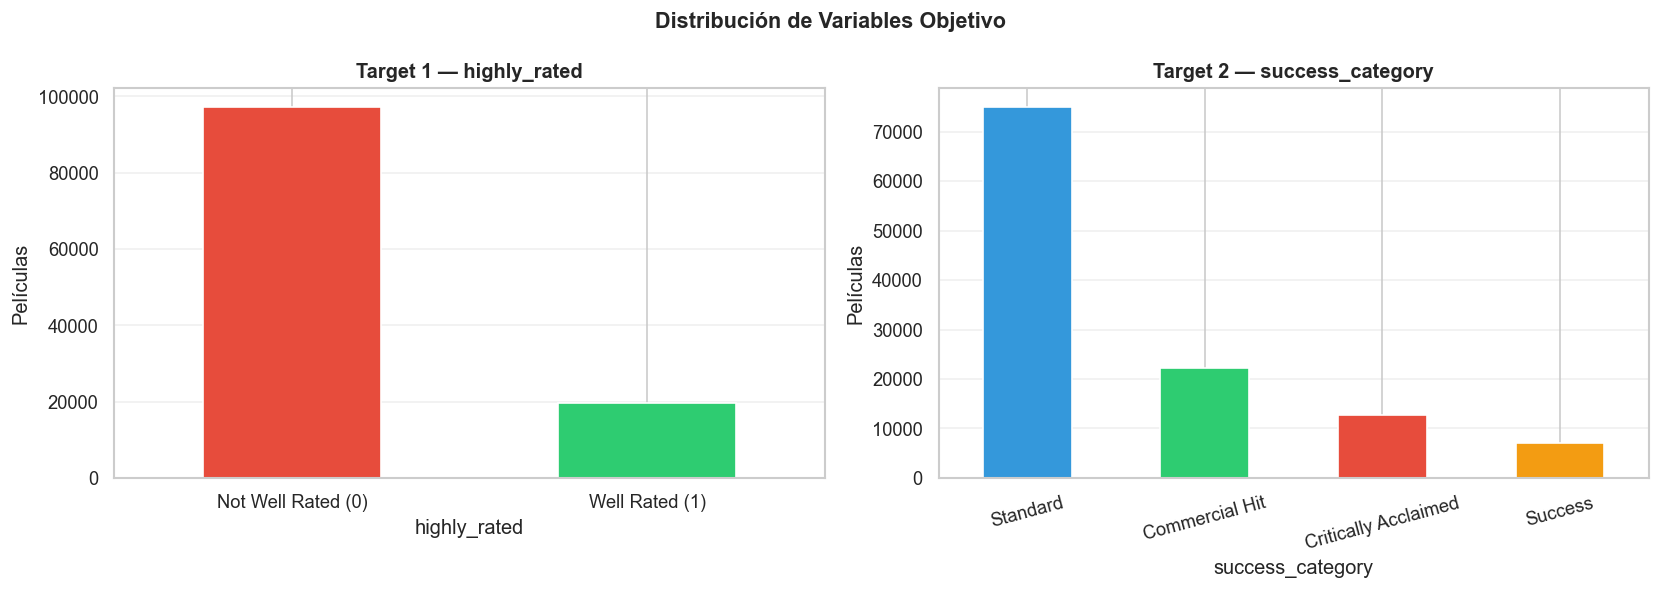

In [5]:
# ── Target 1: highly_rated (ya existe) ───────────────────────────────────────

# ── Target 2: success_category ───────────────────────────────────────────────
pop_threshold = df['popularity'].quantile(0.75)

# Fix: usar default='' y dtype explícito para numpy 2.0+
conditions = [
    (df['highly_rated'] == 1) & (df['popularity'] > pop_threshold),
    (df['highly_rated'] == 1) & (df['popularity'] <= pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] > pop_threshold),
    (df['highly_rated'] == 0) & (df['popularity'] <= pop_threshold),
]
choices = ['Success', 'Critically Acclaimed', 'Commercial Hit', 'Standard']
df['success_category'] = np.select(conditions, choices, default='Standard').astype(str)

# Distribuciones
print("── Target 1: highly_rated ──────────────────────────────")
print(df['highly_rated'].value_counts(normalize=True).round(3))

print("\n── Target 2: success_category ──────────────────────────")
print(df['success_category'].value_counts(normalize=True).round(3))

# Visualización distribución targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['highly_rated'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'],
    edgecolor='white', rot=0
)
axes[0].set_title('Target 1 — highly_rated', fontweight='bold')
axes[0].set_xticklabels(['Not Well Rated (0)', 'Well Rated (1)'])
axes[0].set_ylabel('Películas')
axes[0].grid(alpha=0.3, axis='y')

df['success_category'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#3498db','#2ecc71','#e74c3c','#f39c12'],
    edgecolor='white', rot=15
)
axes[1].set_title('Target 2 — success_category', fontweight='bold')
axes[1].set_ylabel('Películas')
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Distribución de Variables Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Unir df con géneros codificados
df_full = pd.concat([df, df_genres], axis=1)

# Construir df_model sin duplicar columnas PCA
cols_necesarias = list(dict.fromkeys(
    FEATURES_C1 + FEATURES_C2 + ['highly_rated', 'success_category']
))

df_model = df_full[cols_necesarias].dropna().reset_index(drop=True)

# Reconstruir X para cada clasificación
X_c1   = df_model[FEATURES_C1].values
X_c2   = df_model[FEATURES_C2].values
X_base = df_model[FEATURES_BASE].values

y1 = df_model['highly_rated'].values

le_success = LabelEncoder()
y2_enc     = le_success.fit_transform(df_model['success_category'].values)
CLASS_NAMES = le_success.classes_

print(f"Registros para modelado: {len(y1):,}")
print(f"Shape X_c1  (NB + RF, C1): {X_c1.shape}")
print(f"Shape X_c2  (NB + RF, C2): {X_c2.shape}")
print(f"Shape X_base (Red Bayesiana): {X_base.shape}")
print(f"Clases success_category: {CLASS_NAMES}")

Registros para modelado: 116,929
Shape X_c1  (NB + RF, C1): (116929, 29)
Shape X_c2  (NB + RF, C2): (116929, 30)
Shape X_base (Red Bayesiana): (116929, 6)
Clases success_category: ['Commercial Hit' 'Critically Acclaimed' 'Standard' 'Success']


In [7]:
def evaluar_cv(nombre, modelo, X, y, cv=10, promedio='weighted'):
    """
    Validación cruzada estratificada 10-fold.
    promedio='binary' para clasificación binaria,
    promedio='weighted' para multiclase.
    """
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    # sklearn no acepta 'precision_binary' — para binario usa 'precision' sin sufijo
    if promedio == 'binary':
        scoring = {
            'accuracy':  'accuracy',
            'precision': 'precision',
            'recall':    'recall',
            'f1':        'f1',
        }
    else:
        scoring = {
            'accuracy':  'accuracy',
            'precision': f'precision_{promedio}',
            'recall':    f'recall_{promedio}',
            'f1':        f'f1_{promedio}',
        }

    res = cross_validate(modelo, X, y, cv=skf,
                         scoring=scoring, return_train_score=False)

    metricas = {
        'Modelo':    nombre,
        'Accuracy':  round(res['test_accuracy'].mean(),  4),
        'Precision': round(res['test_precision'].mean(), 4),
        'Recall':    round(res['test_recall'].mean(),    4),
        'F1-Score':  round(res['test_f1'].mean(),        4),
    }

    print(f"\n{'─'*55}")
    print(f"  {nombre}")
    print(f"{'─'*55}")
    for k, v in metricas.items():
        if k != 'Modelo':
            print(f"   {k:12}: {v:.4f}")

    return metricas

In [8]:
print("═"*55)
print("  CLASIFICACIÓN 1: highly_rated")
print("═"*55)

nb1 = GaussianNB()
res_nb1 = evaluar_cv("Naive Bayes — highly_rated", nb1, X_c1, y1, promedio='binary')

═══════════════════════════════════════════════════════
  CLASIFICACIÓN 1: highly_rated
═══════════════════════════════════════════════════════



───────────────────────────────────────────────────────
  Naive Bayes — highly_rated
───────────────────────────────────────────────────────
   Accuracy    : 0.7887
   Precision   : 0.3752
   Recall      : 0.3891
   F1-Score    : 0.3820


In [9]:
rf1 = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
res_rf1 = evaluar_cv("Random Forest — highly_rated", rf1, X_c1, y1, promedio='binary')


───────────────────────────────────────────────────────
  Random Forest — highly_rated
───────────────────────────────────────────────────────
   Accuracy    : 0.9960
   Precision   : 0.9820
   Recall      : 0.9943
   F1-Score    : 0.9882


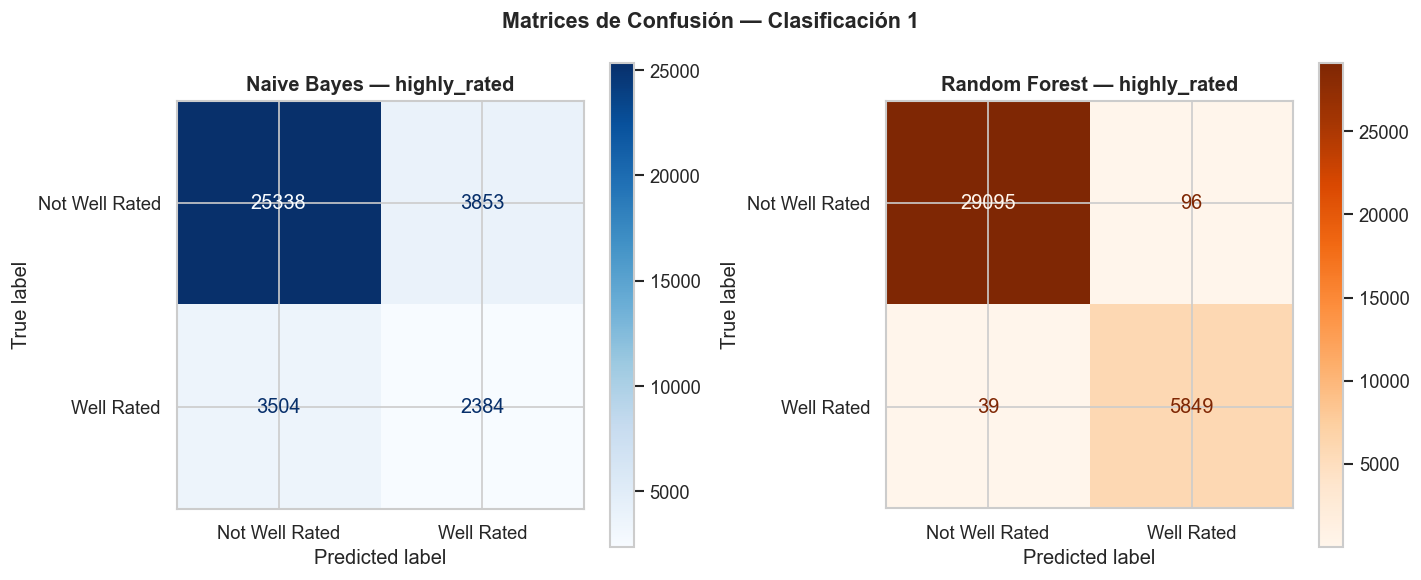


Classification Report — Naive Bayes:
                precision    recall  f1-score   support

Not Well Rated       0.88      0.87      0.87     29191
    Well Rated       0.38      0.40      0.39      5888

      accuracy                           0.79     35079
     macro avg       0.63      0.64      0.63     35079
  weighted avg       0.80      0.79      0.79     35079


Classification Report — Random Forest:
                precision    recall  f1-score   support

Not Well Rated       1.00      1.00      1.00     29191
    Well Rated       0.98      0.99      0.99      5888

      accuracy                           1.00     35079
     macro avg       0.99      1.00      0.99     35079
  weighted avg       1.00      1.00      1.00     35079



In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_c1, y1, test_size=0.3, random_state=42, stratify=y1
)

nb1_vis = GaussianNB().fit(X_tr, y_tr)
y_pred_nb1 = nb1_vis.predict(X_te)

rf1_vis = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
).fit(X_tr, y_tr)
y_pred_rf1 = rf1_vis.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_nb1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Naive Bayes — highly_rated', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_rf1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title('Random Forest — highly_rated', fontweight='bold')

plt.suptitle('Matrices de Confusión — Clasificación 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report — Naive Bayes:")
print(classification_report(y_te, y_pred_nb1,
      target_names=['Not Well Rated', 'Well Rated']))

print("\nClassification Report — Random Forest:")
print(classification_report(y_te, y_pred_rf1,
      target_names=['Not Well Rated', 'Well Rated']))

C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(



Red Bayesiana — highly_rated (muestra 5,000):
   Accuracy    : 0.8317
   Precision   : 0.4571
   Recall      : 0.0019
   F1-Score    : 0.0038


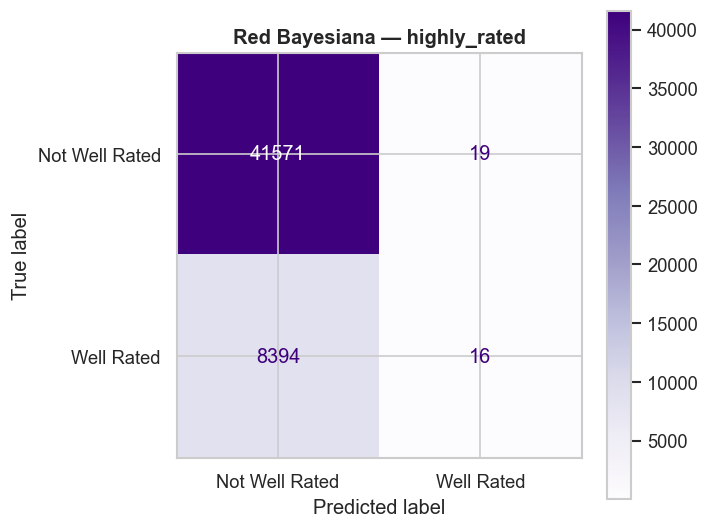

In [11]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.parameter_estimator import DiscreteMLE

disc1 = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
X_base_disc = disc1.fit_transform(X_base).astype(int)

df_bn1 = pd.DataFrame(X_base_disc, columns=[f'{c}_bin' for c in FEATURES_BASE])
df_bn1['highly_rated'] = y1

estructura_bn1 = [
    ('vote_count_bin',      'highly_rated'),
    ('runtime_bin',         'highly_rated'),
    ('release_year_bin',    'highly_rated'),
    ('adult_int_bin',       'highly_rated'),
    ('lang_encoded_bin',    'highly_rated'),
    ('duration_encoded_bin','highly_rated'),
    ('vote_count_bin',      'release_year_bin'),
    ('release_year_bin',    'duration_encoded_bin'),
]

bn1 = DiscreteBayesianNetwork(estructura_bn1)
bn1.fit(df_bn1, estimator=DiscreteMLE())
infer1 = VariableElimination(bn1)

def predecir_bn(infer, feature_cols, X_disc, target, umbral=0.5):
    preds = []
    for fila in X_disc:
        evidencia = {f'{col}_bin': int(val)
                     for col, val in zip(feature_cols, fila)}
        try:
            q = infer.query([target], evidence=evidencia, show_progress=False)
            prob_pos = q.values[-1]
            preds.append(1 if prob_pos >= umbral else 0)
        except Exception:
            preds.append(0)
    return np.array(preds)

np.random.seed(42)
idx_s = np.random.choice(len(y1), size=50000, replace=False)
y_pred_bn1 = predecir_bn(infer1, FEATURES_BASE, X_base_disc[idx_s], 'highly_rated')
y_s1 = y1[idx_s]

res_bn1 = {
    'Modelo':    'Red Bayesiana — highly_rated',
    'Accuracy':  round(accuracy_score(y_s1,  y_pred_bn1), 4),
    'Precision': round(precision_score(y_s1, y_pred_bn1, zero_division=0), 4),
    'Recall':    round(recall_score(y_s1,    y_pred_bn1, zero_division=0), 4),
    'F1-Score':  round(f1_score(y_s1,        y_pred_bn1, zero_division=0), 4),
}

print("\nRed Bayesiana — highly_rated (muestra 5,000):")
for k, v in res_bn1.items():
    if k != 'Modelo':
        print(f"   {k:12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_s1, y_pred_bn1,
    display_labels=['Not Well Rated', 'Well Rated'],
    cmap='Purples', ax=ax
)
ax.set_title('Red Bayesiana — highly_rated', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print("═"*55)
print("  CLASIFICACIÓN 2: success_category")
print("═"*55)

nb2 = GaussianNB()
res_nb2 = evaluar_cv("Naive Bayes — success_category", nb2, X_c2, y2_enc, promedio='weighted')

═══════════════════════════════════════════════════════
  CLASIFICACIÓN 2: success_category
═══════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  Naive Bayes — success_category
───────────────────────────────────────────────────────
   Accuracy    : 0.7749
   Precision   : 0.7603
   Recall      : 0.7749
   F1-Score    : 0.7644


In [13]:
rf2 = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced',
    random_state=42, n_jobs=-1
)
res_rf2 = evaluar_cv("Random Forest — success_category", rf2, X_c2, y2_enc, promedio='weighted')


───────────────────────────────────────────────────────
  Random Forest — success_category
───────────────────────────────────────────────────────
   Accuracy    : 0.9258
   Precision   : 0.9283
   Recall      : 0.9258
   F1-Score    : 0.9267


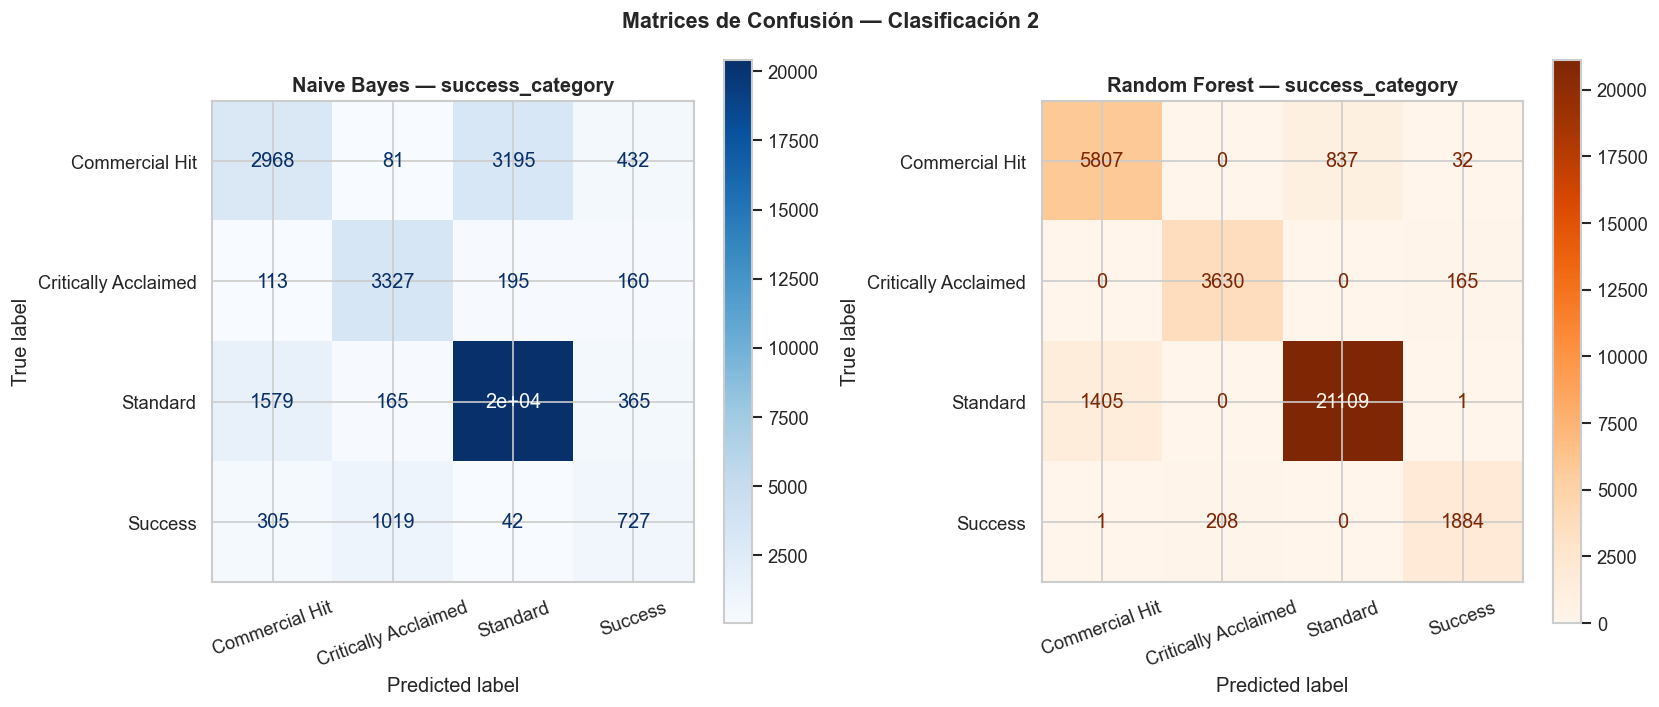


Classification Report — Naive Bayes:
                      precision    recall  f1-score   support

      Commercial Hit       0.60      0.44      0.51      6676
Critically Acclaimed       0.72      0.88      0.79      3795
            Standard       0.86      0.91      0.88     22515
             Success       0.43      0.35      0.38      2093

            accuracy                           0.78     35079
           macro avg       0.65      0.64      0.64     35079
        weighted avg       0.77      0.78      0.77     35079


Classification Report — Random Forest:
                      precision    recall  f1-score   support

      Commercial Hit       0.81      0.87      0.84      6676
Critically Acclaimed       0.95      0.96      0.95      3795
            Standard       0.96      0.94      0.95     22515
             Success       0.90      0.90      0.90      2093

            accuracy                           0.92     35079
           macro avg       0.90      0.92      0.

In [14]:
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_c2, y2_enc, test_size=0.3, random_state=42, stratify=y2_enc
)

nb2_vis = GaussianNB().fit(X_tr2, y_tr2)
y_pred_nb2 = nb2_vis.predict(X_te2)

rf2_vis = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
).fit(X_tr2, y_tr2)
y_pred_rf2 = rf2_vis.predict(X_te2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_te2, y_pred_nb2,
    display_labels=CLASS_NAMES,
    cmap='Blues', ax=axes[0], xticks_rotation=20
)
axes[0].set_title('Naive Bayes — success_category', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_te2, y_pred_rf2,
    display_labels=CLASS_NAMES,
    cmap='Oranges', ax=axes[1], xticks_rotation=20
)
axes[1].set_title('Random Forest — success_category', fontweight='bold')

plt.suptitle('Matrices de Confusión — Clasificación 2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report — Naive Bayes:")
print(classification_report(y_te2, y_pred_nb2, target_names=CLASS_NAMES))

print("\nClassification Report — Random Forest:")
print(classification_report(y_te2, y_pred_rf2, target_names=CLASS_NAMES))


Red Bayesiana — success_category (muestra 5,000):
   Accuracy    : 0.1883
   Precision   : 0.0355
   Recall      : 0.1883
   F1-Score    : 0.0597


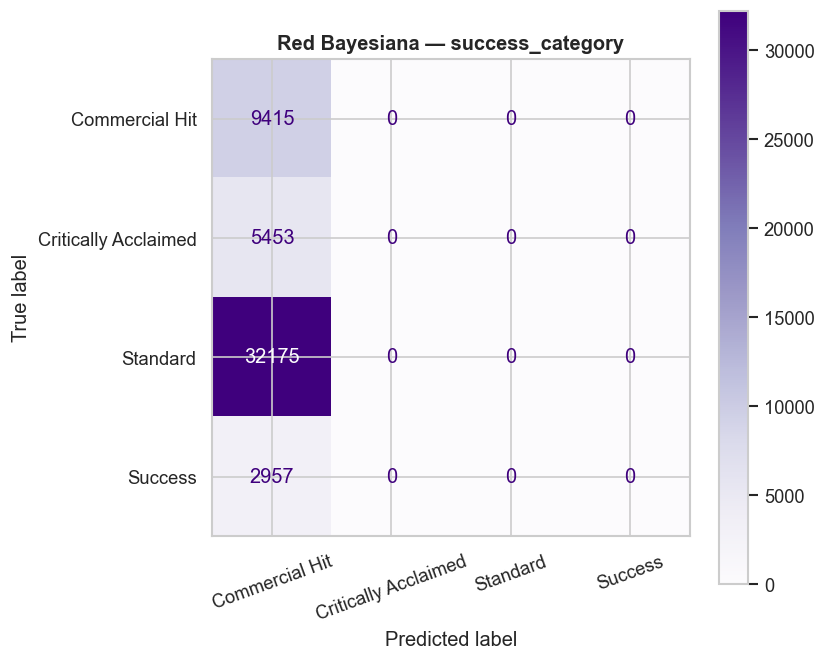

In [15]:
df_bn2 = pd.DataFrame(X_base_disc, columns=[f'{c}_bin' for c in FEATURES_BASE])
df_bn2['success_category'] = y2_enc

estructura_bn2 = [
    ('vote_count_bin',       'success_category'),
    ('runtime_bin',          'success_category'),
    ('release_year_bin',     'success_category'),
    ('adult_int_bin',        'success_category'),
    ('lang_encoded_bin',     'success_category'),
    ('duration_encoded_bin', 'success_category'),
    ('vote_count_bin',       'release_year_bin'),
    ('release_year_bin',     'duration_encoded_bin'),
]

bn2 = DiscreteBayesianNetwork(estructura_bn2)
bn2.fit(df_bn2, estimator=DiscreteMLE())
infer2 = VariableElimination(bn2)

y_pred_bn2 = predecir_bn(infer2, FEATURES_BASE, X_base_disc[idx_s], 'success_category')
y_s2 = y2_enc[idx_s]

res_bn2 = {
    'Modelo':    'Red Bayesiana — success_category',
    'Accuracy':  round(accuracy_score(y_s2,  y_pred_bn2), 4),
    'Precision': round(precision_score(y_s2, y_pred_bn2,
                        average='weighted', zero_division=0), 4),
    'Recall':    round(recall_score(y_s2,    y_pred_bn2,
                        average='weighted', zero_division=0), 4),
    'F1-Score':  round(f1_score(y_s2,        y_pred_bn2,
                        average='weighted', zero_division=0), 4),
}

print("\nRed Bayesiana — success_category (muestra 5,000):")
for k, v in res_bn2.items():
    if k != 'Modelo':
        print(f"   {k:12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_s2, y_pred_bn2,
    display_labels=CLASS_NAMES,
    cmap='Purples', ax=ax, xticks_rotation=20
)
ax.set_title('Red Bayesiana — success_category', fontweight='bold')
plt.tight_layout()
plt.show()

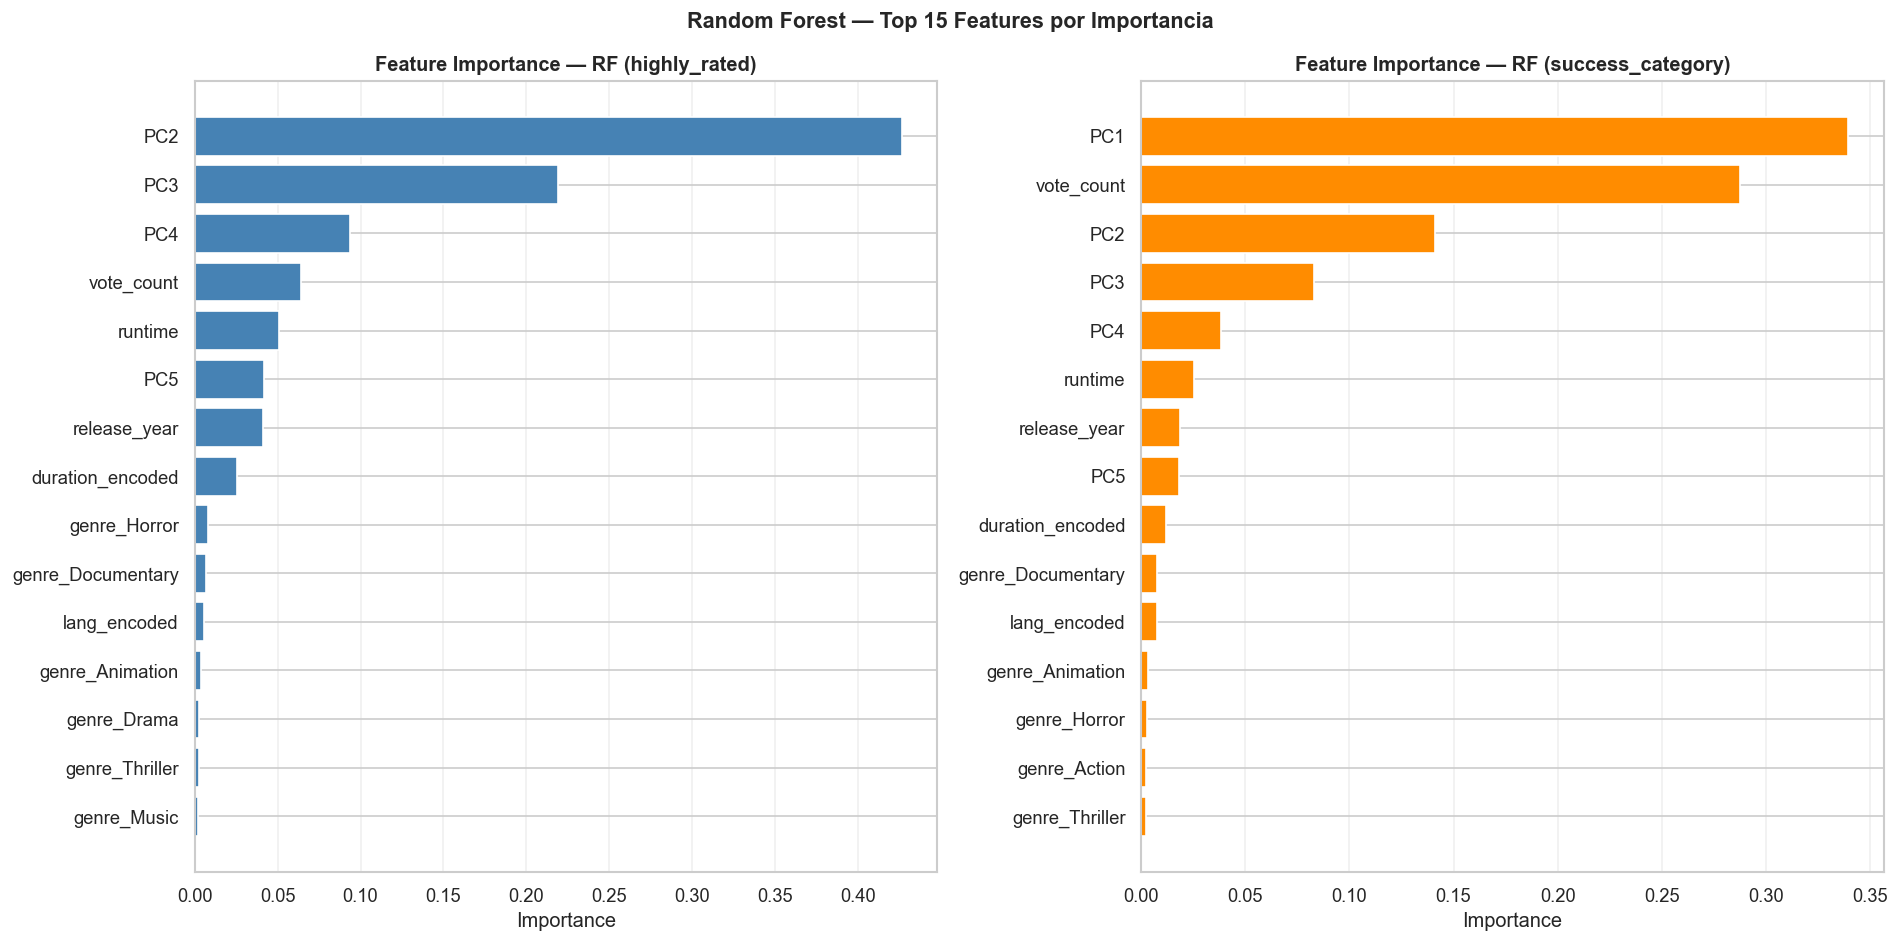

In [16]:
# Entrenar sobre conjunto completo para feature importance
rf1_vis = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
).fit(X_c1, y1)

rf2_vis = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
).fit(X_c2, y2_enc)

# Top 15 features más importantes para no saturar el gráfico
def plot_top_importance(ax, importances, feature_names, titulo, color, top_n=15):
    indices = np.argsort(importances)[-top_n:]
    ax.barh([feature_names[i] for i in indices],
            importances[indices],
            color=color, edgecolor='white')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(alpha=0.3, axis='x')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plot_top_importance(axes[0], rf1_vis.feature_importances_,
                    FEATURES_C1, 'Feature Importance — RF (highly_rated)', 'steelblue')

plot_top_importance(axes[1], rf2_vis.feature_importances_,
                    FEATURES_C2, 'Feature Importance — RF (success_category)', 'darkorange')

plt.suptitle('Random Forest — Top 15 Features por Importancia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
todos = [
    res_nb1, res_bn1, res_rf1,
    res_nb2, res_bn2, res_rf2,
]

tabla = pd.DataFrame(todos).set_index('Modelo')

print("="*65)
print("  COMPARATIVA FINAL — CLASIFICACIÓN TMDB")
print("="*65)
display(tabla.style
        .highlight_max(color='lightgreen', axis=0)
        .highlight_min(color='#ffcccc',    axis=0)
        .format("{:.4f}"))

print("\nNota: F1-Score es la métrica principal.")
print("      Clasificación 1 usa F1 binary | Clasificación 2 usa F1 weighted.")
print("      Red Bayesiana evaluada sobre muestra de 5,000 registros.")

  COMPARATIVA FINAL — CLASIFICACIÓN TMDB


,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Naive Bayes — highly_rated,0.7887,0.3752,0.3891,0.3820
Red Bayesiana — highly_rated,0.8317,0.4571,0.0019,0.0038
Random Forest — highly_rated,0.9960,0.9820,0.9943,0.9882
Naive Bayes — success_category,0.7749,0.7603,0.7749,0.7644
Red Bayesiana — success_category,0.1883,0.0355,0.1883,0.0597
Random Forest — success_category,0.9258,0.9283,0.9258,0.9267



Nota: F1-Score es la métrica principal.
      Clasificación 1 usa F1 binary | Clasificación 2 usa F1 weighted.
      Red Bayesiana evaluada sobre muestra de 5,000 registros.


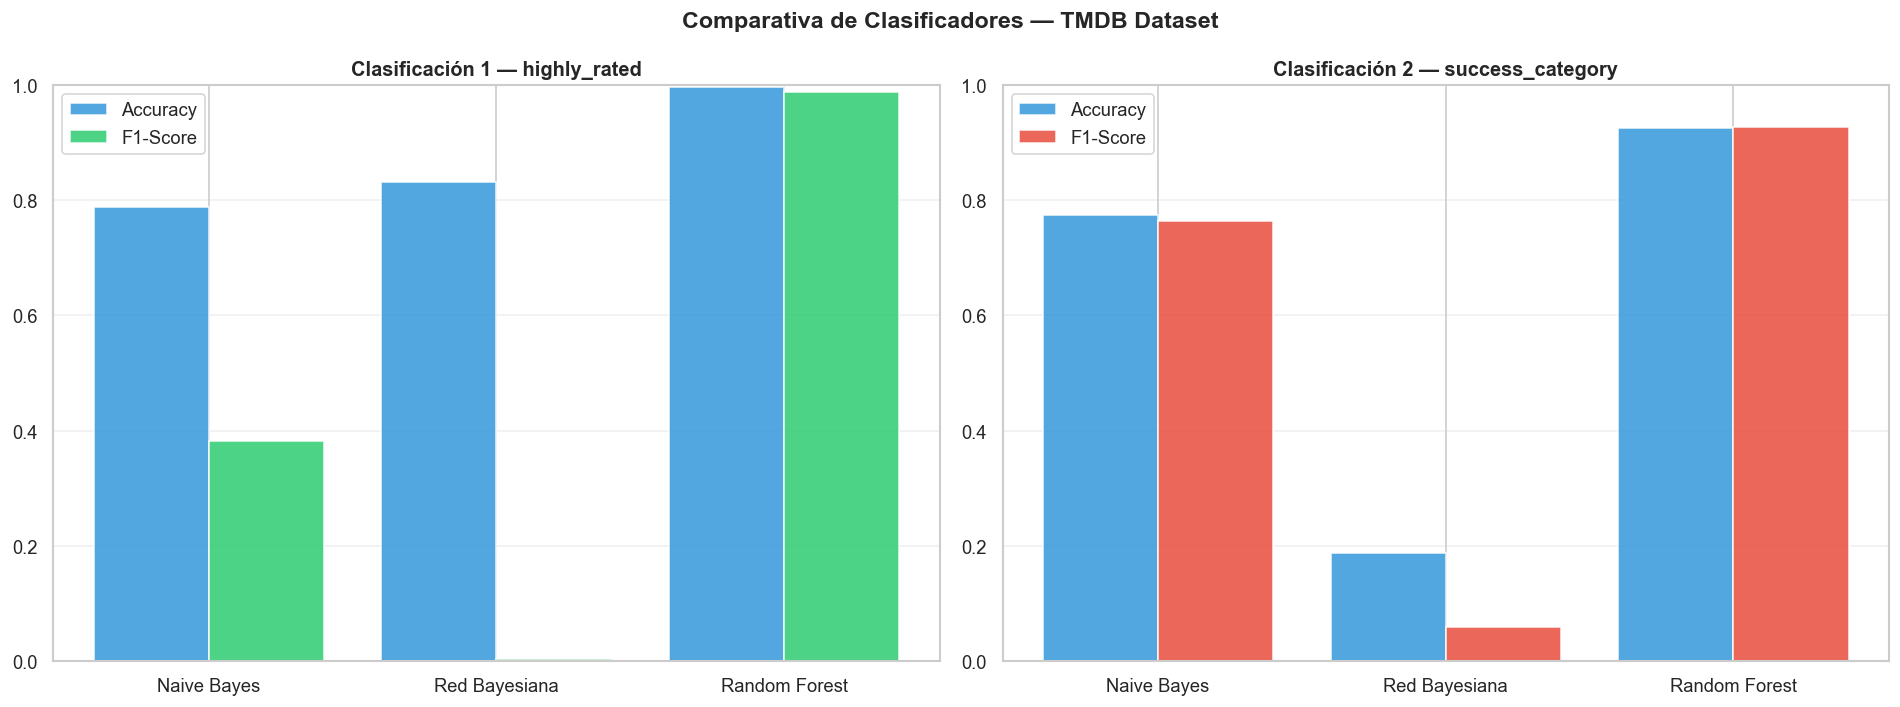

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Clasificación 1
modelos1  = ['Naive Bayes', 'Red Bayesiana', 'Random Forest']
f1_vals1  = [res_nb1['F1-Score'], res_bn1['F1-Score'], res_rf1['F1-Score']]
acc_vals1 = [res_nb1['Accuracy'], res_bn1['Accuracy'], res_rf1['Accuracy']]

x1 = np.arange(len(modelos1))
axes[0].bar(x1 - 0.2, acc_vals1, 0.4, label='Accuracy',
            color='#3498db', alpha=0.85, edgecolor='white')
axes[0].bar(x1 + 0.2, f1_vals1,  0.4, label='F1-Score',
            color='#2ecc71', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(modelos1)
axes[0].set_title('Clasificación 1 — highly_rated', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# ── Clasificación 2
modelos2  = ['Naive Bayes', 'Red Bayesiana', 'Random Forest']
f1_vals2  = [res_nb2['F1-Score'], res_bn2['F1-Score'], res_rf2['F1-Score']]
acc_vals2 = [res_nb2['Accuracy'], res_bn2['Accuracy'], res_rf2['Accuracy']]

x2 = np.arange(len(modelos2))
axes[1].bar(x2 - 0.2, acc_vals2, 0.4, label='Accuracy',
            color='#3498db', alpha=0.85, edgecolor='white')
axes[1].bar(x2 + 0.2, f1_vals2,  0.4, label='F1-Score',
            color='#e74c3c', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(modelos2)
axes[1].set_title('Clasificación 2 — success_category', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Comparativa de Clasificadores — TMDB Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
def clasificar_pelicula(titulo, vote_count, runtime, release_year,
                         adult, original_language, duration_bin, genres):
    print(f"\n{'═'*55}")
    print(f"  Película: {titulo}")
    print(f"{'═'*55}")
    print(f"  Votos: {vote_count} | Duración: {runtime} min | Año: {release_year}")
    print(f"  Idioma: {original_language} | Adult: {adult}")
    print(f"  Duración categoría: {duration_bin}")
    print(f"  Géneros: {genres}")

    # ── Features base ─────────────────────────────────────────────────────────
    lang = original_language if original_language in top_langs else 'other'
    lang_enc  = le.transform([lang])[0]
    adult_enc = int(adult)
    dur_enc   = duration_map.get(duration_bin, 1)
    base      = [vote_count, runtime, release_year, adult_enc, lang_enc, dur_enc]

    # ── Géneros — garantizar mismo orden que en entrenamiento ─────────────────
    genre_vec  = mlb.transform([genres])
    genre_vals = genre_vec[0].tolist()

    # ── PCA — aproximar con medianas del grupo de duración ────────────────────
    pca_medians = df_full.groupby('duration_bin')[['PC1','PC2','PC3','PC4','PC5']].median()
    pca_vals    = pca_medians.loc[duration_bin].values  # shape (5,)

    # ── Vector C1: base + PC2-PC5 + genres ────────────────────────────────────
    x_c1 = np.array(base + list(pca_vals[1:]) + genre_vals).reshape(1, -1)

    # ── Vector C2: base + PC1-PC5 + genres ────────────────────────────────────
    x_c2 = np.array(base + list(pca_vals) + genre_vals).reshape(1, -1)

    # ── Verificación de dimensiones ───────────────────────────────────────────
    assert x_c1.shape[1] == nb1_vis.n_features_in_, \
        f"C1: esperaba {nb1_vis.n_features_in_} features, got {x_c1.shape[1]}"
    assert x_c2.shape[1] == nb2_vis.n_features_in_, \
        f"C2: esperaba {nb2_vis.n_features_in_} features, got {x_c2.shape[1]}"

    # ── Predicciones ──────────────────────────────────────────────────────────
    pred_nb1  = nb1_vis.predict(x_c1)[0]
    pred_nb2  = le_success.inverse_transform(nb2_vis.predict(x_c2))[0]
    prob_nb1  = nb1_vis.predict_proba(x_c1)[0]
    prob_nb2  = nb2_vis.predict_proba(x_c2)[0]

    pred_rf1  = rf1_vis.predict(x_c1)[0]
    pred_rf2  = le_success.inverse_transform(rf2_vis.predict(x_c2))[0]
    prob_rf1  = rf1_vis.predict_proba(x_c1)[0]
    prob_rf2  = rf2_vis.predict_proba(x_c2)[0]

    hr_labels = ['Not Well Rated', 'Well Rated']

    print(f"\n  {'─'*50}")
    print(f"  CLASIFICACIÓN 1 — ¿Será bien valorada?")
    print(f"  {'─'*50}")
    print(f"  Naive Bayes  : {hr_labels[pred_nb1]}")
    print(f"    Probs → No: {prob_nb1[0]:.3f} | Sí: {prob_nb1[1]:.3f}")
    print(f"  Random Forest: {hr_labels[pred_rf1]}")
    print(f"    Probs → No: {prob_rf1[0]:.3f} | Sí: {prob_rf1[1]:.3f}")

    print(f"\n  {'─'*50}")
    print(f"  CLASIFICACIÓN 2 — ¿Tipo de éxito?")
    print(f"  {'─'*50}")
    print(f"  Naive Bayes  : {pred_nb2}")
    for cls, prob in zip(CLASS_NAMES, prob_nb2):
        print(f"    {cls:25}: {prob:.3f}")
    print(f"  Random Forest: {pred_rf2}")
    for cls, prob in zip(CLASS_NAMES, prob_rf2):
        print(f"    {cls:25}: {prob:.3f}")

In [20]:
# Ejemplo 1 — película tipo blockbuster
clasificar_pelicula(
    titulo            = "Película Blockbuster",
    vote_count        = 15000,
    runtime           = 148,
    release_year      = 2019,
    adult             = False,
    original_language = 'en',
    duration_bin      = 'Very long',
    genres            = ['Action', 'Science Fiction', 'Adventure']
)

# Ejemplo 2 — película independiente
clasificar_pelicula(
    titulo            = "Película Independiente",
    vote_count        = 200,
    runtime           = 95,
    release_year      = 2015,
    adult             = False,
    original_language = 'fr',
    duration_bin      = 'Standard',
    genres            = ['Drama', 'Romance']
)

# Ejemplo 3 — película de terror de bajo presupuesto
clasificar_pelicula(
    titulo            = "Película de Terror",
    vote_count        = 500,
    runtime           = 85,
    release_year      = 2022,
    adult             = False,
    original_language = 'en',
    duration_bin      = 'Short',
    genres            = ['Horror', 'Thriller']
)


═══════════════════════════════════════════════════════
  Película: Película Blockbuster
═══════════════════════════════════════════════════════
  Votos: 15000 | Duración: 148 min | Año: 2019
  Idioma: en | Adult: False
  Duración categoría: Very long
  Géneros: ['Action', 'Science Fiction', 'Adventure']

  ──────────────────────────────────────────────────
  CLASIFICACIÓN 1 — ¿Será bien valorada?
  ──────────────────────────────────────────────────
  Naive Bayes  : Well Rated
    Probs → No: 0.000 | Sí: 1.000
  Random Forest: Well Rated
    Probs → No: 0.446 | Sí: 0.554

  ──────────────────────────────────────────────────
  CLASIFICACIÓN 2 — ¿Tipo de éxito?
  ──────────────────────────────────────────────────
  Naive Bayes  : Success
    Commercial Hit           : 0.000
    Critically Acclaimed     : 0.000
    Standard                 : 0.000
    Success                  : 1.000
  Random Forest: Commercial Hit
    Commercial Hit           : 0.843
    Critically Acclaimed     : 0.003